# MCDI504 - Machine Learning I
## Sumativa 1 - Avance del proyecto, Fase 1: Definición y orientación de la situación

**Caso:** IrisFlow - clasificación de especies Iris  
**Dataset:** Iris (`sklearn.datasets.load_iris`)  
**Integrantes:** Enzo Pinilla, Claudio Alarcón y Luis Rodrigo Espinoza  
**Docente:** David Ruete Zúñiga  
**Grupo:** 2  
**Fecha:** 09-08-2026  
**Repositorio del grupo:** https://github.com/sauriomac/MCDI504_MACHINE_LEARNING_1_GRUPO_2


## 0. Reproducibilidad del entorno

Se conserva como base el trabajo inicial de configuración local/Colab. Para reproducir el notebook se requiere Python 3 y las librerías `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn` y `scipy`.

La estructura final se adapta al repositorio real del grupo:

```text
MCDI504_MACHINE_LEARNING_1_GRUPO_2/
├── docs/
│   └── MCDI504_S1_1_GRUPO2.pdf
├── figures/
├── notebooks/
│   └── F1_Definicion.ipynb
├── .gitignore
├── README.md
└── requirements.txt
```

**Instalación local (terminal):**
```bash
python -m venv .venv
source .venv/bin/activate   # macOS/Linux
# .venv\Scripts\activate  # Windows
python -m pip install -r requirements.txt
```

**Google Colab/Jupyter:**
```python
%pip install pandas numpy seaborn matplotlib scikit-learn scipy
```

`.venv/` y `.ipynb_checkpoints/` son elementos locales y deben permanecer excluidos mediante `.gitignore`. La ejecución posterior usa solo recursos incluidos en las librerías; no requiere descargar el dataset desde Internet.


## 1. Definición analítica del problema

### 1.1 Contexto y situación de análisis
IrisFlow se utiliza como **escenario ficticio** de recepción y clasificación de flores ornamentales. La clasificación manual de flores Iris puede depender de la observación de características morfológicas y del criterio humano. La situación analítica consiste en estudiar si cuatro medidas cuantitativas permiten sustentar posteriormente una clasificación automática de la especie.

### 1.2 Pregunta analítica
**¿En qué medida las variables `Sepal.Length`, `Sepal.Width`, `Petal.Length` y `Petal.Width` permiten sustentar un enfoque de aprendizaje supervisado para clasificar una flor Iris como setosa, versicolor o virginica?**

### 1.3 Objetivo general
Definir y justificar el enfoque metodológico inicial de Machine Learning para la clasificación multiclase de especies Iris, mediante la caracterización estructural, descriptiva y exploratoria de los datos y su articulación con las etapas de KDD.

### 1.4 Objetivos específicos
1. Caracterizar la estructura, tipos de variables, calidad y balance del dataset.
2. Describir las variables predictoras mediante estadística descriptiva y visualizaciones.
3. Analizar asociaciones lineales **entre las variables predictoras continuas** mediante correlación de Pearson y p-valores.
4. Explorar la separabilidad de las especies mediante distribuciones agrupadas por `Species`.
5. Demostrar una normalización Min-Max de las variables de entrada como preparación técnica, sin asumir que será obligatoria para todos los algoritmos futuros.
6. Justificar el aprendizaje supervisado de clasificación multiclase y compararlo con alternativas.
7. Relacionar cada decisión y evidencia del notebook con las etapas de KDD.

### 1.5 Alcance y viabilidad
La Fase 1 es descriptiva, exploratoria y metodológica: no incluye entrenamiento, validación ni comparación de modelos. La viabilidad inicial es alta porque existen 150 observaciones con una etiqueta de especie conocida y cuatro predictores numéricos; la capacidad predictiva real deberá demostrarse en fases posteriores mediante modelos y métricas. Este alcance responde a las orientaciones de la tarea para esta etapa del proyecto (Ruete Zúñiga, 2026a).


## 2. Preparación del entorno y carga del dataset

El dataset se carga mediante `sklearn.datasets.load_iris`, de acuerdo con la documentación oficial de scikit-learn (scikit-learn developers, s. f.). Se utilizan nombres de columnas coherentes con el apunte y código fuente del curso. `Species` se conserva como variable categórica nominal.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f"{x:.4f}")

# Permite ejecutar desde la raíz del repo o desde /notebooks.
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

iris = load_iris()
bbdd1 = pd.DataFrame(
    iris.data,
    columns=['Sepal.Length', 'Sepal.Width', 'Petal.Length', 'Petal.Width']
)
bbdd1['Species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f"Dataset cargado: {bbdd1.shape[0]} filas x {bbdd1.shape[1]} columnas")
display(bbdd1.head())


Dataset cargado: 150 filas x 5 columnas


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1000,3.5000,1.4000,0.2000,setosa
1,4.9000,3.0000,1.4000,0.2000,setosa
2,4.7000,3.2000,1.3000,0.2000,setosa
3,4.6000,3.1000,1.5000,0.2000,setosa
4,5.0000,3.6000,1.4000,0.2000,setosa


## 3. Exploración y calidad de datos

La revisión de forma, tipos, valores faltantes, duplicados y balance de clases mediante estructuras y operaciones de `pandas` permite sostener las decisiones metodológicas con evidencia del propio dataset (pandas development team, s. f.).


In [2]:
print('Tipos de datos:')
print(bbdd1.dtypes)
print()
print('Valores nulos por columna:')
print(bbdd1.isna().sum())
print()
print('Registros duplicados exactos:', int(bbdd1.duplicated().sum()))
print()
print('Distribución de Species:')
print(bbdd1['Species'].value_counts().sort_index())


Tipos de datos:
Sepal.Length     float64
Sepal.Width      float64
Petal.Length     float64
Petal.Width      float64
Species         category
dtype: object

Valores nulos por columna:
Sepal.Length    0
Sepal.Width     0
Petal.Length    0
Petal.Width     0
Species         0
dtype: int64

Registros duplicados exactos: 1

Distribución de Species:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [3]:
resumen = bbdd1.describe(include='all').T

data_quality = pd.DataFrame({
    'variable': bbdd1.columns,
    'tipo': [str(t) for t in bbdd1.dtypes],
    'nulos': bbdd1.isna().sum().values,
    'unicos': [bbdd1[c].nunique() for c in bbdd1.columns]
})

display(resumen)
display(data_quality)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Sepal.Length,150.0000,NaN,NaN,NaN,5.8433,0.8281,4.3000,5.1000,5.8000,6.4000,7.9000
Sepal.Width,150.0000,NaN,NaN,NaN,3.0573,0.4359,2.0000,2.8000,3.0000,3.3000,4.4000
Petal.Length,150.0000,NaN,NaN,NaN,3.7580,1.7653,1.0000,1.6000,4.3500,5.1000,6.9000
Petal.Width,150.0000,NaN,NaN,NaN,1.1993,0.7622,0.1000,0.3000,1.3000,1.8000,2.5000
Species,150,3,setosa,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,variable,tipo,nulos,unicos
0,Sepal.Length,float64,0,35
1,Sepal.Width,float64,0,23
2,Petal.Length,float64,0,43
3,Petal.Width,float64,0,22
4,Species,category,0,3


**Decisión sobre el registro duplicado.** Se documenta un duplicado exacto, pero no se elimina en esta fase porque el dataset no dispone de un identificador que permita determinar si corresponde a un error de captura o a dos observaciones legítimas con las mismas medidas. Antes de una futura partición entrenamiento/prueba, su tratamiento deberá decidirse explícitamente para evitar que copias idénticas queden repartidas entre subconjuntos.


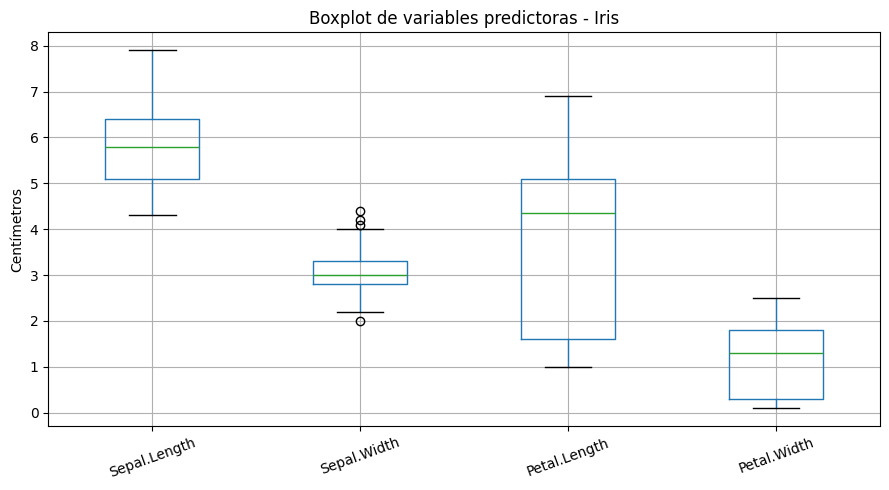

In [4]:
plt.figure(figsize=(9,5))
bbdd1[['Sepal.Length','Sepal.Width','Petal.Length','Petal.Width']].boxplot()
plt.title('Boxplot de variables predictoras - Iris')
plt.ylabel('Centímetros')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_boxplot_general.png', dpi=180, bbox_inches='tight')
plt.show()


## 4. Clasificación del tipo de aprendizaje

- **Variable objetivo:** `Species`, categórica nominal de tres clases conocidas.
- **Predictores:** cuatro variables numéricas continuas.
- **Propósito:** asignar una clase de especie a partir de medidas observadas.

Por estas condiciones, el enfoque principal es **aprendizaje supervisado de clasificación multiclase**. No corresponde regresión porque la salida no es continua; el clustering puede ser exploratorio, pero ignoraría una etiqueta disponible; y el aprendizaje por refuerzo exige agente, acciones secuenciales y señal de recompensa, elementos ausentes en este problema (Alpaydin, 2010; Géron, 2019; Provost & Fawcett, 2013).


In [5]:
X = bbdd1[['Sepal.Length','Sepal.Width','Petal.Length','Petal.Width']].copy()
y = bbdd1['Species'].copy()

clasificacion = pd.DataFrame({
    'Elemento': ['Variable objetivo','Etiquetas','Predictores','Número de clases','Decisión'],
    'Evidencia': [
        'Species - categórica nominal',
        'Conocidas para las 150 observaciones',
        '4 variables numéricas continuas',
        '3: setosa, versicolor, virginica',
        'Aprendizaje supervisado - clasificación multiclase'
    ]
})
display(clasificacion)


,Elemento,Evidencia
0,Variable objetivo,Species - categórica nominal
1,Etiquetas,Conocidas para las 150 observaciones
2,Predictores,4 variables numéricas continuas
3,Número de clases,"3: setosa, versicolor, virginica"
4,Decisión,Aprendizaje supervisado - clasificación multic...


## 5. Relación entre Machine Learning y metodología KDD

KDD organiza el proceso completo de descubrimiento de conocimiento. Machine Learning se proyecta principalmente en la etapa de minería de datos, mientras que esta Fase 1 deja evidencia en selección, preprocesamiento y transformación/preparación (Fayyad et al., 1996).

| Etapa KDD | Función concreta en este proyecto | Evidencia en Fase 1 |
|---|---|---|
| Selección | Elegir las variables morfológicas y la etiqueta pertinentes para la pregunta analítica. | `load_iris()`, construcción de `bbdd1`, definición de `X` e `y`. |
| Preprocesamiento | Verificar estructura, tipos, nulos, duplicados, balance y valores potencialmente atípicos. | `dtypes`, `isna()`, `duplicated()`, `describe()`, boxplot. |
| Transformación | Preparar variables para su uso posterior sin alterar el significado de `Species`. | Demostración Min-Max solo sobre `X`; `Species` permanece categórica. Pearson se usa como análisis exploratorio entre continuas, no como transformación. |
| Minería de datos / ML | Entrenar algoritmos de clasificación supervisada. | **No se ejecuta en Fase 1**; queda planificado para F2-F4. |
| Interpretación | Evaluar desempeño y utilidad del conocimiento/modelo. | En Fase 1 se interpretan evidencias exploratorias; la evaluación predictiva se realizará después. |


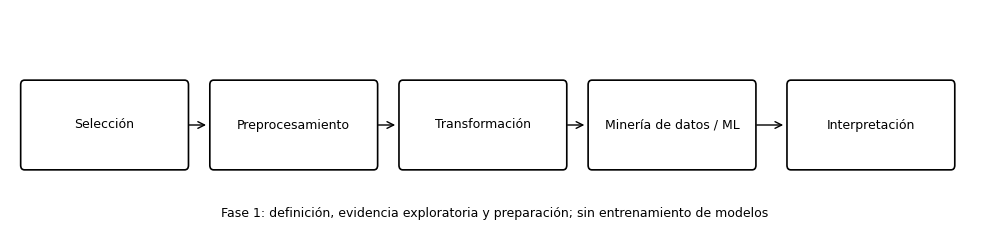

In [6]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
fig, ax = plt.subplots(figsize=(10,2.6))
ax.set_xlim(0, 10); ax.set_ylim(0, 2); ax.axis('off')
stages = ['Selección','Preprocesamiento','Transformación','Minería de datos / ML','Interpretación']
xs = [0.15,2.1,4.05,6.0,8.05]
for i,(x,label) in enumerate(zip(xs,stages)):
    box = FancyBboxPatch((x,0.65),1.65,0.7,boxstyle='round,pad=0.04',linewidth=1.2,facecolor='white')
    ax.add_patch(box)
    ax.text(x+0.825,1.0,label,ha='center',va='center',fontsize=9,wrap=True)
    if i < len(stages)-1:
        ax.add_patch(FancyArrowPatch((x+1.67,1.0),(xs[i+1]-0.05,1.0),arrowstyle='->',mutation_scale=12))
ax.text(5,0.2,'Fase 1: definición, evidencia exploratoria y preparación; sin entrenamiento de modelos',ha='center',fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / '01_flujo_kdd.png', dpi=180, bbox_inches='tight')
plt.show()


## 6. Evidencia estadística: correlación de Pearson

### 6.1 Decisión metodológica sobre `Species`
La correlación de Pearson se calcula **solo entre las cuatro variables predictoras continuas**. Aunque una categoría puede codificarse técnicamente con números, `Species` es nominal y sus códigos no representan distancias ni un orden natural. Por eso no se usa una correlación Pearson con `Species` como evidencia de separabilidad.

La relación entre predictores y especie se examina después mediante visualizaciones agrupadas por clase. Esta decisión conserva el sentido estadístico de Pearson y evita interpretar códigos de categoría como magnitudes. El cálculo del coeficiente y su p-valor se realiza con `scipy.stats.pearsonr`, siguiendo el material del curso y la documentación oficial (Ruete Zúñiga, 2026b; SciPy community, s. f.).


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Sepal.Length,1.0000,-0.1176,0.8718,0.8179
Sepal.Width,-0.1176,1.0000,-0.4284,-0.3661
Petal.Length,0.8718,-0.4284,1.0000,0.9629
Petal.Width,0.8179,-0.3661,0.9629,1.0000


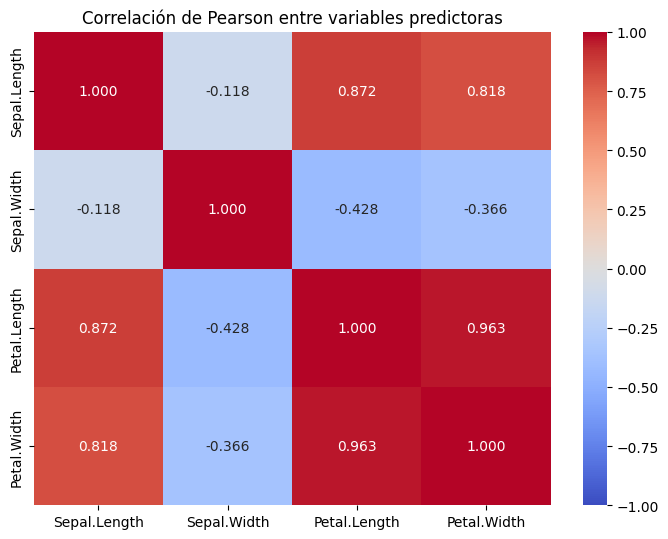

In [7]:
corr = X.corr(method='pearson')
display(corr)

plt.figure(figsize=(7,5.5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación de Pearson entre variables predictoras')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_correlacion_pearson.png', dpi=180, bbox_inches='tight')
plt.show()


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Sepal.Length,0.0000,0.1519,0.0000,0.0000
Sepal.Width,0.1519,0.0000,0.0000,0.0000
Petal.Length,0.0000,0.0000,0.0000,0.0000
Petal.Width,0.0000,0.0000,0.0000,0.0000


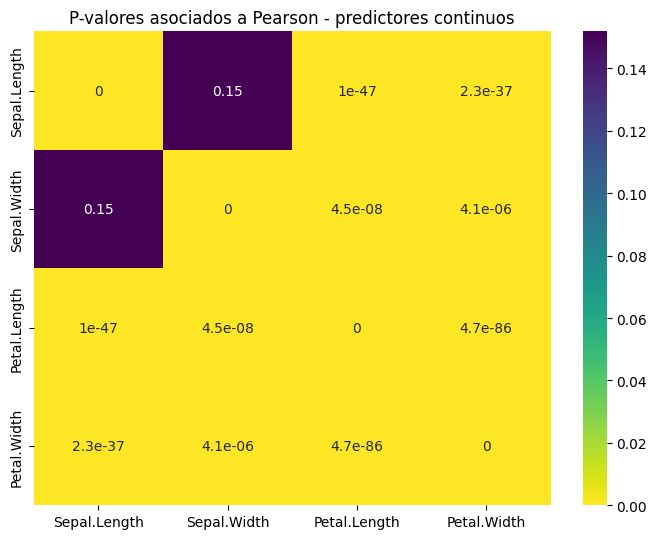

In [8]:
def calculate_pvalues(df):
    cols = df.columns
    pvals = pd.DataFrame(np.ones((len(cols), len(cols))), index=cols, columns=cols)
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if i == j:
                pvals.loc[c1,c2] = 0.0
            else:
                _, p = pearsonr(df[c1], df[c2])
                pvals.loc[c1,c2] = p
    return pvals

pvalues = calculate_pvalues(X)
display(pvalues)

plt.figure(figsize=(7,5.5))
sns.heatmap(pvalues, annot=True, fmt='.2g', cmap='viridis_r')
plt.title('P-valores asociados a Pearson - predictores continuos')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_pvalores_pearson.png', dpi=180, bbox_inches='tight')
plt.show()


### 6.2 Interpretación
`Petal.Length` y `Petal.Width` presentan una correlación lineal muy alta (aprox. 0,963). `Sepal.Length` también se asocia fuertemente con ambas variables del pétalo. En cambio, `Sepal.Length` y `Sepal.Width` presentan una relación débil (aprox. -0,118) y su p-valor es cercano a 0,152, por lo que no se observa evidencia suficiente de asociación lineal al nivel 0,05. Los p-valores pequeños indican evidencia contra la hipótesis de correlación cero, pero **no demuestran capacidad predictiva ni causalidad**.


## 7. Separabilidad exploratoria entre especies

Para estudiar la relación entre las variables predictoras y una etiqueta categórica se comparan sus distribuciones por `Species`. Esto complementa Pearson sin imponer una codificación ordinal artificial a la especie.


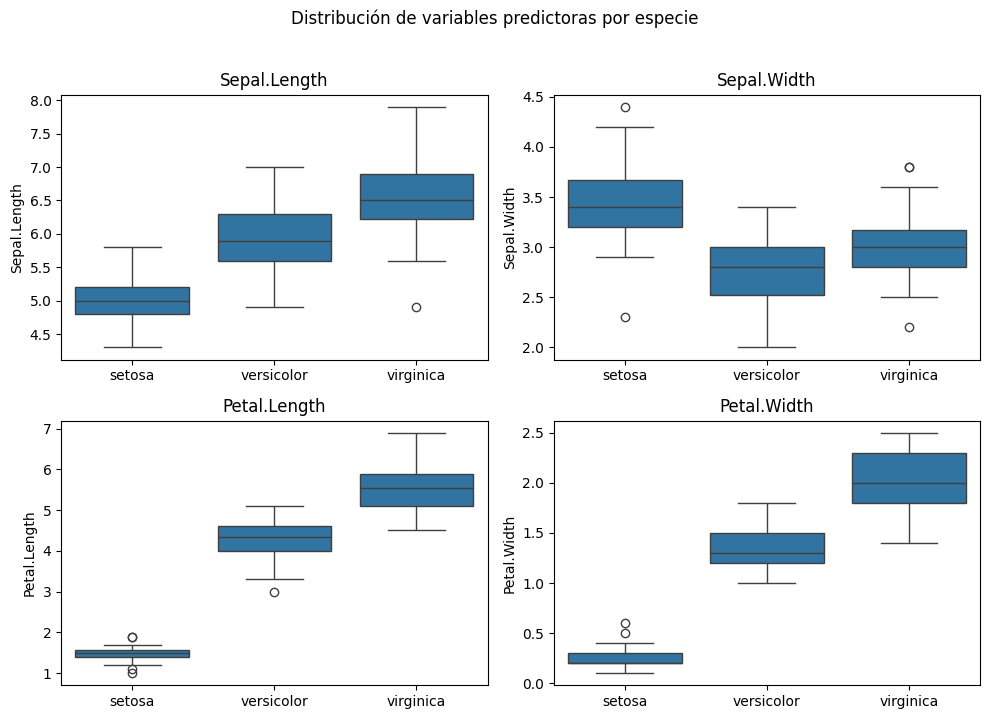

In [9]:
fig, axes = plt.subplots(2,2,figsize=(10,7))
for ax, col in zip(axes.ravel(), X.columns):
    sns.boxplot(data=bbdd1, x='Species', y=col, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Distribución de variables predictoras por especie', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_boxplots_por_especie.png', dpi=180, bbox_inches='tight')
plt.show()


Las variables del pétalo muestran diferencias visuales más marcadas entre especies, particularmente para setosa. `Sepal.Width` presenta mayor solapamiento. Este resultado es evidencia exploratoria de separabilidad potencial, pero el desempeño real solo podrá establecerse al entrenar y evaluar clasificadores en fases posteriores.


## 8. Normalización Min-Max como preparación, no como modelamiento

El apunte y código docente incorpora la normalización Min-Max (Ruete Zúñiga, 2026b). Aquí se reproduce de manera controlada **solo sobre las cuatro variables predictoras**. Se conserva `Species` categórica. La transformación se documenta como evidencia de preparación: su uso definitivo dependerá del algoritmo seleccionado en F2, porque no todos los métodos tienen la misma sensibilidad a la escala.


In [10]:
scaler = MinMaxScaler()
X_norm = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
bbdd_norm = pd.concat([X_norm, y.rename('Species')], axis=1)
display(bbdd_norm.head())


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,0.2222,0.6250,0.0678,0.0417,setosa
1,0.1667,0.4167,0.0678,0.0417,setosa
2,0.1111,0.5000,0.0508,0.0417,setosa
3,0.0833,0.4583,0.0847,0.0417,setosa
4,0.1944,0.6667,0.0678,0.0417,setosa


## 9. Comparación de enfoques y justificación del descarte

| Enfoque | Señal/dato requerido | Uso típico | Aplicación al caso / factibilidad |
|---|---|---|---|
| **Supervisado - clasificación** | Predictores + etiqueta categórica conocida | Predecir una clase | **Seleccionado.** `Species` está disponible para todos los registros y el objetivo es predecir una de tres clases. |
| No supervisado - clustering | Predictores sin necesidad de etiquetas | Descubrir grupos o estructura | Puede ser complementario para explorar similitudes, pero como enfoque principal desaprovecha `Species` y no responde directamente al objetivo de clasificar clases conocidas. |
| Por refuerzo | Estado, acciones, interacción secuencial y recompensa | Optimizar una política de decisiones | No es factible aquí: cada flor se clasifica de forma independiente; no existe agente, entorno secuencial ni recompensa acumulada. |
| Supervisado - regresión | Variable objetivo numérica continua | Estimar un valor continuo | Se descarta para el objetivo central porque `Species` es categórica. Sería pertinente solo si la pregunta buscara estimar una medida numérica. |

La clasificación supervisada es la opción más coherente por estructura de datos, variable objetivo, utilidad esperada y factibilidad técnica.


## 10. Documentación y trazabilidad de decisiones

| Decisión/cambio | Por qué se adopta | Evidencia / ubicación |
|---|---|---|
| Mantener el escenario IrisFlow como contexto ficticio | Da sentido operativo a una pregunta que de otro modo sería solo descriptiva. | Sección 1 e informe. |
| Conservar `Species` como categórica | Es una variable nominal; evita imponer orden artificial. | Carga de `bbdd1`, definición de `y`. |
| Pearson solo entre predictores continuos | Pearson mide asociación lineal numérica; la etiqueta se estudia por grupos. | Sección 6 + Figura 03 y matriz mostrada en la salida. |
| Incorporar p-valores | Permite complementar la magnitud de `r` con evidencia estadística contra correlación cero. | `calculate_pvalues()` + Figura 04. |
| Documentar el duplicado y no borrarlo aún | Falta identificador/contexto para saber si es error o repetición legítima. | Sección 3 y salida de `duplicated()`. |
| Incluir Min-Max sin entrenar modelos | Reproduce la preparación docente y deja evidencia de transformación; su necesidad final depende del algoritmo. | Sección 8 y salida visible de `bbdd_norm.head()`. |
| Guardar solo figuras como artefactos generados | La rúbrica exige evidencia y trazabilidad, pero no una carpeta `outputs/`; se mantiene el repo simple. | `figures/` y celdas ejecutadas del notebook. |
| No entrenar modelos | La Fase 1 evalúa definición, enfoque, KDD y evidencia inicial. | Todo el notebook; no hay `fit()` de clasificadores. |


## 11. Conclusiones de la Fase 1

1. El problema queda formulado como **clasificación supervisada multiclase**, porque `Species` es una etiqueta categórica conocida y el objetivo es asignar una clase a partir de cuatro medidas continuas.
2. La base presenta 150 observaciones, sin valores faltantes y con 50 registros por clase; se detecta un duplicado exacto que se deja documentado para una decisión posterior.
3. La exploración muestra asociaciones lineales fuertes entre variables del pétalo y diferencias visuales por especie. Estas señales justifican avanzar al modelamiento, pero no equivalen todavía a desempeño predictivo demostrado.
4. Pearson se aplica únicamente a los predictores continuos; `Species` se conserva como nominal. Esta distinción mejora la validez de la interpretación frente a una codificación numérica meramente técnica.
5. La normalización Min-Max se demuestra como preparación reproducible de `X`, sin asumir que sea obligatoria para todos los clasificadores futuros.
6. En KDD, la Fase 1 cubre selección, preprocesamiento y preparación/transformación; la minería de datos y evaluación se proyectan a F2-F4.


## 12. Evidencias generadas y ubicación en el repositorio

Al ejecutar el notebook desde `notebooks/` se regeneran directamente en `../figures/`:

- `figures/02_boxplot_general.png`
- `figures/01_flujo_kdd.png`
- `figures/03_correlacion_pearson.png`
- `figures/04_pvalores_pearson.png`
- `figures/05_boxplots_por_especie.png`

Las tablas numéricas (resumen descriptivo, calidad de datos, matriz de correlación, p-valores y muestra normalizada) quedan visibles en las salidas ejecutadas del propio notebook. No se crea una carpeta `outputs/`, porque no es un requisito de la rúbrica y el repositorio del grupo ya dispone de `docs/`, `figures/` y `notebooks/` como estructura principal.

**Repositorio:** https://github.com/sauriomac/MCDI504_MACHINE_LEARNING_1_GRUPO_2

**Verificación antes de entregar:** ejecutar `Restart & Run All`, comprobar que las cinco figuras se regeneren sin errores y confirmar que `notebooks/F1_Definicion.ipynb`, `docs/MCDI504_S1_1_GRUPO2.pdf` y el README describan la misma ruta metodológica.


## 13. Bibliografía

Las decisiones conceptuales y técnicas se sustentan en material docente, documentación oficial y literatura académica. Las citas se integran en los apartados donde se emplean, y el listado siguiente conserva correspondencia con las fuentes citadas.

- Alpaydin, E. (2010). *Introduction to machine learning* (2nd ed.). MIT Press.

- Fayyad, U., Piatetsky-Shapiro, G., & Smyth, P. (1996). From data mining to knowledge discovery in databases. *AI Magazine, 17*(3), 37–54.

- Géron, A. (2019). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (2nd ed.). O’Reilly Media.

- Provost, F., & Fawcett, T. (2013). *Data science for business*. O’Reilly Media.

- Ruete Zúñiga, D. (2026a). *Presentación Tarea Fase 1 MCDI504* [Presentación de clase]. Universidad Andrés Bello.

- Ruete Zúñiga, D. (2026b). *Fase 1: Estadística descriptiva, correlación y normalización de datos* [Apunte y código de clase]. Universidad Andrés Bello.

- pandas development team. (s. f.). *pandas documentation*. [https://pandas.pydata.org/docs/](https://pandas.pydata.org/docs/)

- scikit-learn developers. (s. f.). *The Iris dataset / load_iris*. Scikit-learn documentation. [https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html)

- SciPy community. (s. f.). *scipy.stats.pearsonr*. SciPy documentation. [https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html)
